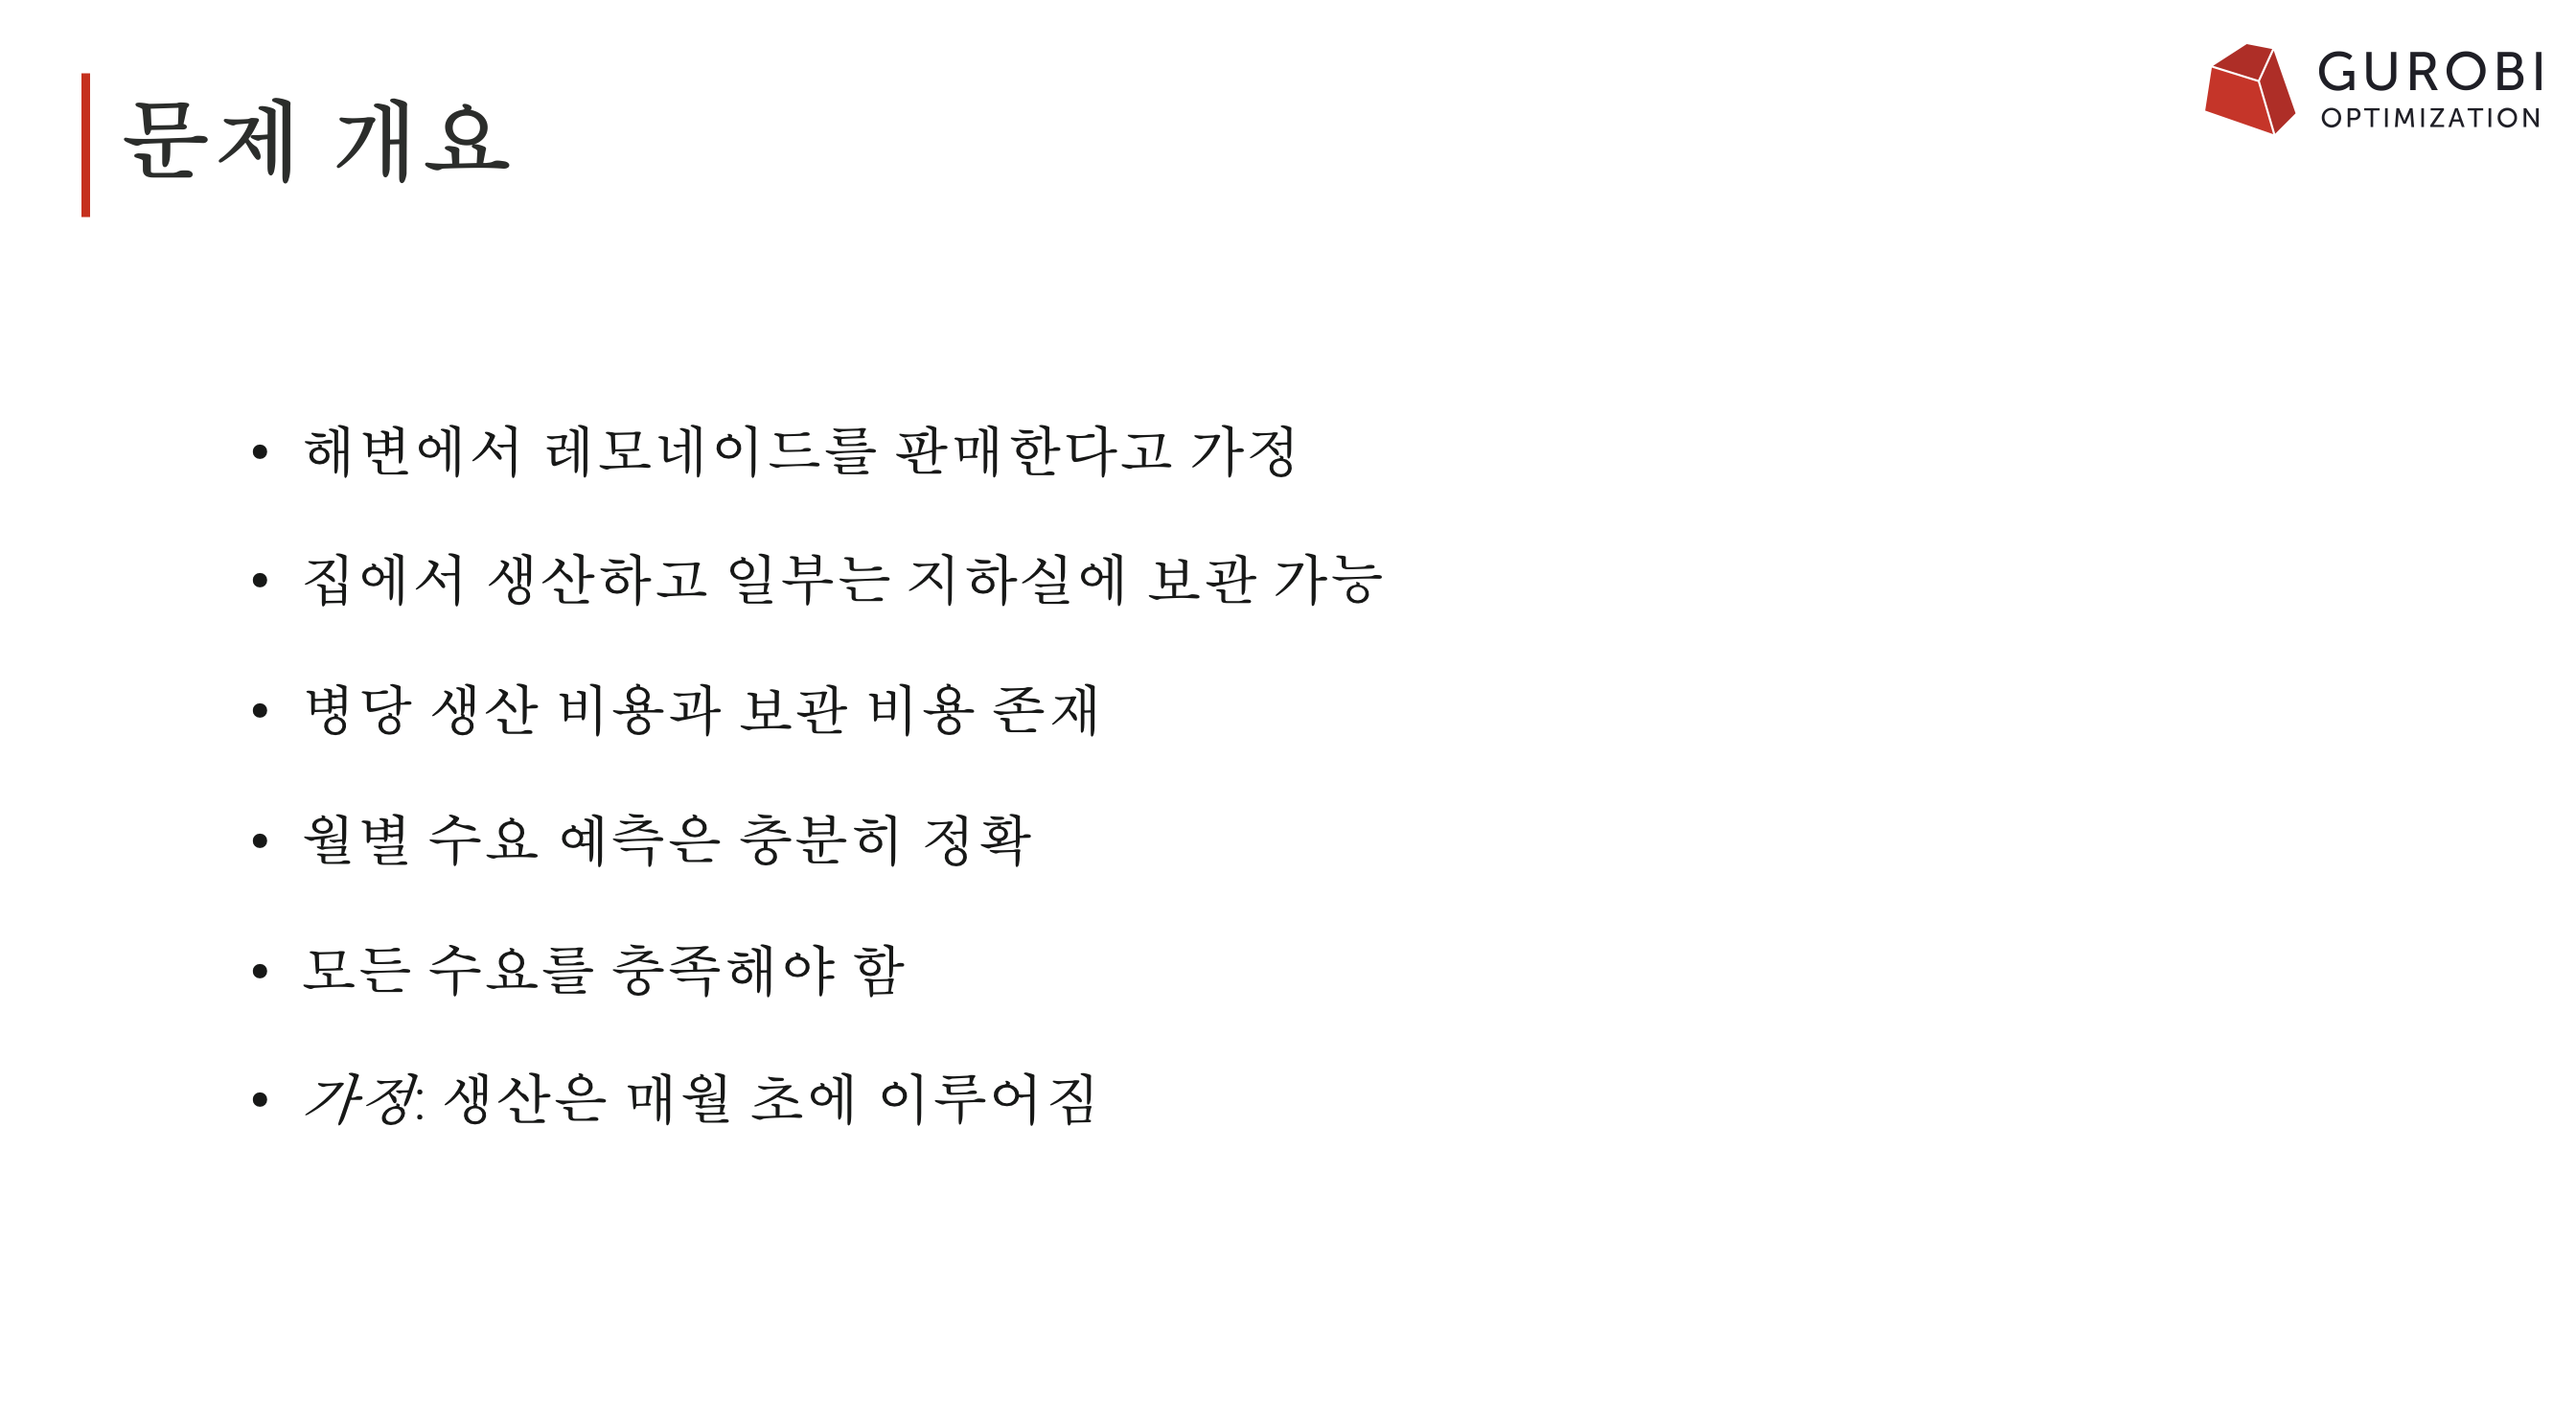

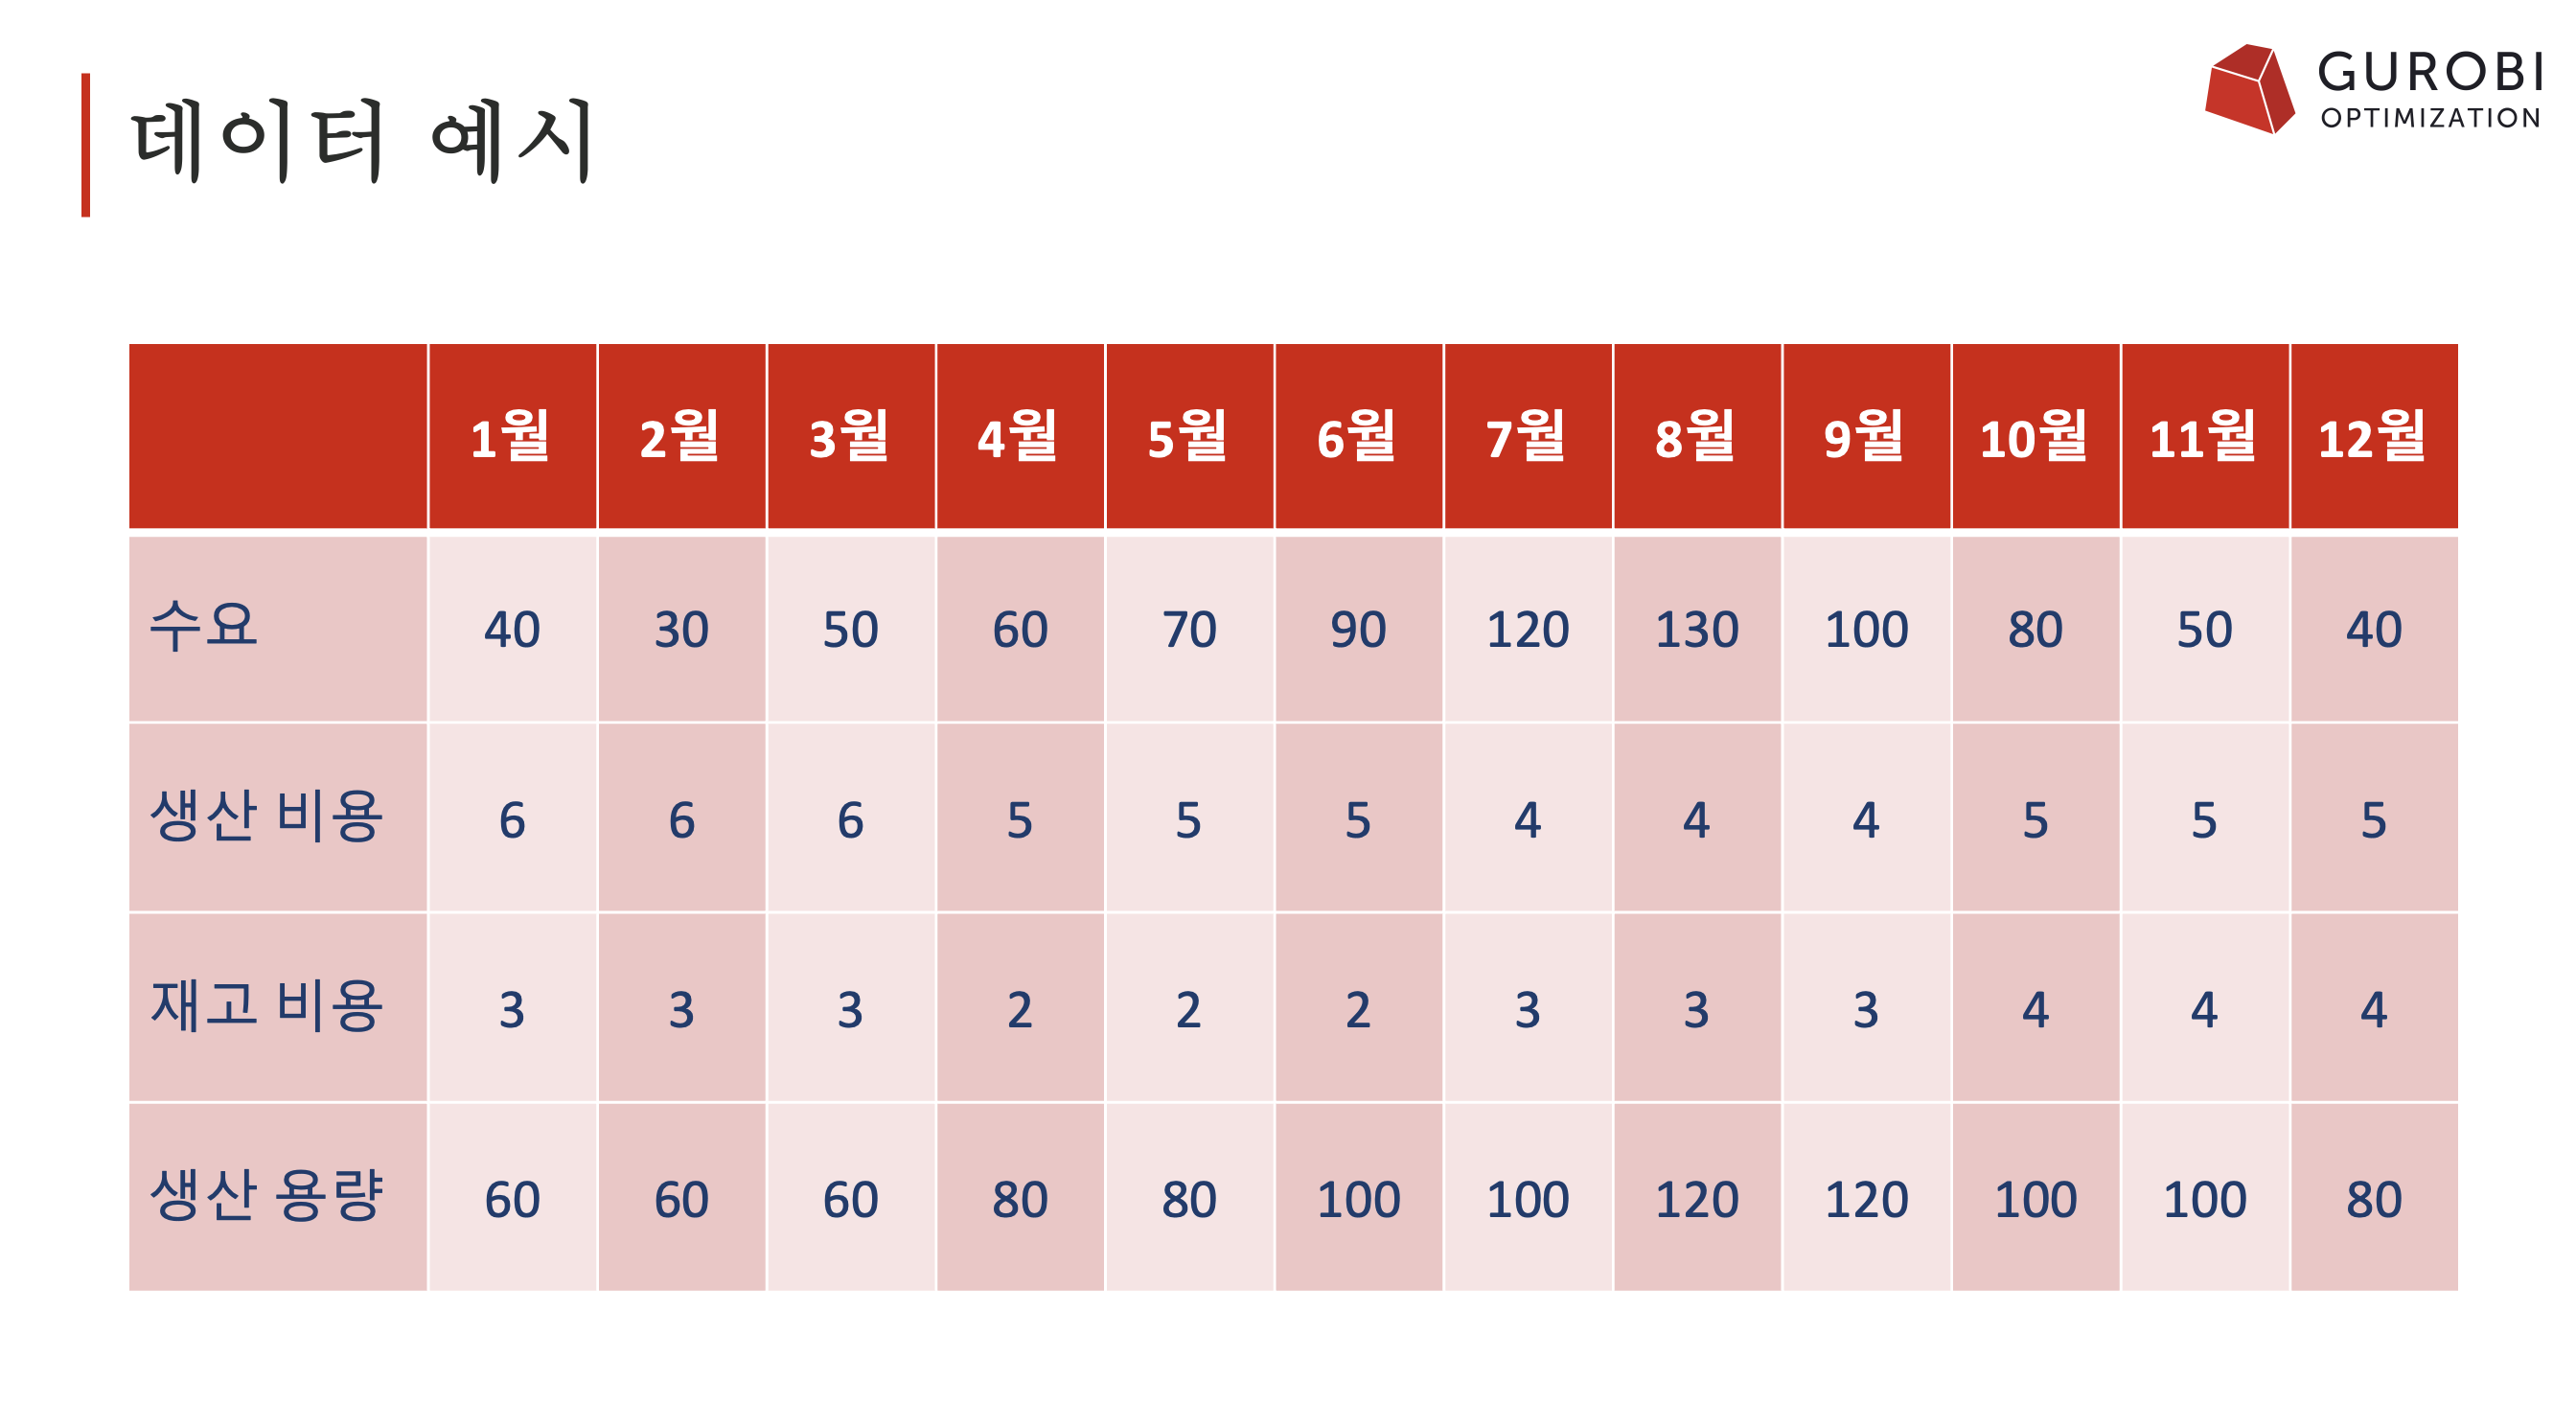

In [ ]:
T = list(range(12))
demand = [40, 30, 50, 60, 70, 90, 120, 130, 100, 80, 50, 40]
production_cost = [6, 6, 6, 5, 5, 5, 4, 4, 4, 5, 5, 5]
holding_cost = [3, 3, 3, 2, 2, 2, 3, 3, 3, 4, 4, 4]
production_capacity = [60, 60, 60, 80, 80, 100, 100, 120, 120, 100, 100, 80]

In [ ]:
# gurobipy 설치 및 페키지 불러오기
!pip install gurobipy
import gurobipy as gp
from gurobipy import GRB

# 모델 및 결정 변수
m = gp.Model('lemonade')
x = m.addVars(T)
y = m.addVars(T)

# 제약 조건
for t in T:
  x[t].UB = production_capacity[t]
  m.addConstrs(
    y[t] == (y[t-1] if t > 0 else 0) + x[t] - demand[t] for t in T
  )

# 목적 함수
m.setObjective(sum(production_cost[t] * x[t] + holding_cost[t] * y[t] for t in T))
m.ModelSense = GRB.MINIMIZE

# Gurobi Optimizer 실행
m.optimize()

Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (linux64 - "Ubuntu 22.04.4 LTS")

CPU model: AMD EPYC 7B12, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 144 rows, 24 columns and 420 nonzeros
Model fingerprint: 0x0ddd1184
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [2e+00, 6e+00]
  Bounds range     [6e+01, 1e+02]
  RHS range        [3e+01, 1e+02]
Presolve removed 137 rows and 5 columns
Presolve time: 0.00s
Presolved: 7 rows, 19 columns, 25 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    6.8993400e+02   8.625137e+01   0.000000e+00      0s
       9    4.2500000e+03   0.000000e+00   0.000000e+00      0s

Solved in 9 iterations and 0.01 seconds (0.00 work units)
Optimal objective  4.250000000e+03


In [ ]:
# 해 출력

for t in T:
  print(f'{t + 1}월: 생산량 {x[t].x}, 재고량 {y[t].x}')

1월: 생산량 40.0, 재고량 0.0
2월: 생산량 30.0, 재고량 0.0
3월: 생산량 50.0, 재고량 0.0
4월: 생산량 70.0, 재고량 10.0
5월: 생산량 80.0, 재고량 20.0
6월: 생산량 100.0, 재고량 30.0
7월: 생산량 100.0, 재고량 10.0
8월: 생산량 120.0, 재고량 0.0
9월: 생산량 100.0, 재고량 0.0
10월: 생산량 80.0, 재고량 0.0
11월: 생산량 50.0, 재고량 0.0
12월: 생산량 40.0, 재고량 0.0
